In [9]:
#Langkah 1: Muat dan Eksplorasi Data

import pandas as pd

URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(URL)

print(df.shape)
print(df["Churn"].value_counts(normalize=True))

(7043, 21)
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [23]:
#Langkah 2: Preprocessing

from sklearn.model_selection import train_test_split

# Pisahkan X (fitur) dan y (target)
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Ubah target Churn menjadi angka
y = y.map({"No": 0, "Yes": 1})

# Encoding fitur kategori
X = pd.get_dummies(X, drop_first=True)

# Train-Test Split 80:20
X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# cek hasil
print(X_tr.shape)
print(X_te.shape)
print(y_tr.shape)
print(y_te.shape)

(5625, 7061)
(1407, 7061)
(5625,)
(1407,)


In [24]:
#Langkah 3: Latih Model

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
n_estimators=300, class_weight="balanced", random_state=42)
rf.fit(X_tr, y_tr)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.8309050012683064


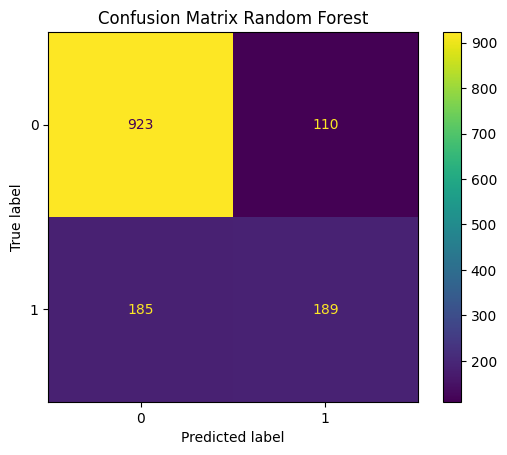

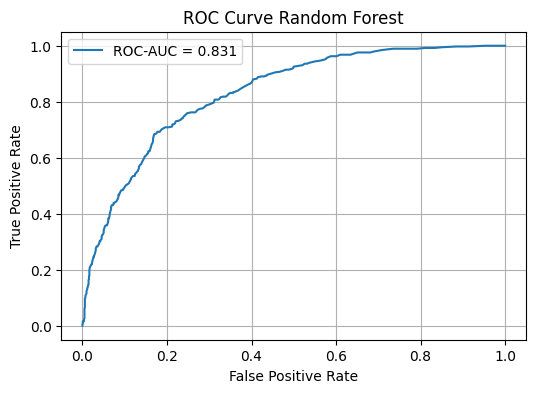

In [27]:
#Langkah 4: Evaluasi

from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, roc_curve
import matplotlib.pyplot as plt

# hitung prediksi
y_pred = rf.predict(X_te)

# hitung probabilitas kelas 1 (churn)
y_prob = rf.predict_proba(X_te)[:,1]


# tampilkan classification report
print(classification_report(y_te, y_pred))


# tampilkan ROC-AUC
print("ROC-AUC:", roc_auc_score(y_te, y_prob))


# Grafik Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_te, y_pred)
plt.title("Confusion Matrix Random Forest")
plt.show()


# Grafik ROC Curve
fpr, tpr, threshold = roc_curve(y_te, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_te, y_prob):.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Random Forest")
plt.legend()
plt.grid()
plt.show()

In [29]:
# Langkah 5: Prediksi Probabilitas dan Kesimpulan

# hitung probabilitas churn
prob_churn = rf.predict_proba(X_te)[:,1]

# tampilkan beberapa probabilitas churn
print(prob_churn[:10])

[0.02       0.73333333 0.01       0.09333333 0.16333333 0.35666667
 0.01333333 0.14       0.74       0.00666667]


Kesimpulan: Berdasarkan hasil analisis menggunakan model Random Forest, data pelanggan diproses dengan baik dan model memiliki kemampuan untuk memprediksi kemungkinan terjadinya churn berdasarkan karakteristik pelanggan. Hasil evaluasi melalui laporan klasifikasi, confusion matrix, dan ROC-AUC menunjukkan bahwa model berhasil mengklasifikasikan pelanggan yang berisiko churn dengan baik. Nilai probabilitas churn dapat membantu bisnis menemukan pelanggan yang memiliki risiko tinggi, sehingga mereka dapat membuat rencana yang lebih baik untuk mencegah churn.